# Notebook: Black-Scholes Model

ใช้ Python 3 และ standard library แล้วเลือก **Run All** ไม่ต้องติดตั้งแพ็กเกจหรือดาวน์โหลดข้อมูล คำอธิบายอ่านจาก `black-scholes-model.md` ตัวเลขและกราฟเป็นตัวอย่างสมมติ ไม่ใช่ข้อมูลตลาด การสุ่มแต่ละชุดระบุ seed; Python และเว็บไซต์ใช้ตัวสุ่มต่างกันจึงไม่จำเป็นต้องได้เส้นทางเดียวกัน Monte Carlo แสดง standard error ภายใต้โมเดล ส่วนการ hedge ใช้ Brownian path ร่วมกันเมื่อเปลี่ยนจำนวน step เพื่อแยกผลของความถี่ในการปรับพอร์ต

[เปิดบทเรียน](https://nutdnuy.github.io/quantitative-finance-notes/black-scholes-model.html)

# Black-Scholes Model

ถ้าราคาหุ้นยังสุ่มอยู่ เราจะหาราคา Option โดยไม่ต้องทายว่าหุ้นจะขึ้นหรือลงได้อย่างไร

ใน [Binomial Model](https://nutdnuy.github.io/quantitative-finance-notes/binomial-model.html) เราหาจำนวนหุ้นและเงินสดที่ให้ผลลัพธ์เท่ากับ Option ได้ทุกแขนง เมื่อพอร์ตสองชุดให้สิ่งเดียวกันในอนาคต หลัก no-arbitrage ก็บังคับให้ต้นทุนวันนี้เท่ากัน

เมื่อย่อ time step จนเข้าสู่เวลาต่อเนื่อง หุ้นไม่ได้มีเพียงสองราคาปลายทาง แต่แนวคิด **เลียนแบบ payoff ด้วยหุ้นและเงินสด** ยังอยู่ บท [Applied Stochastic Calculus](https://nutdnuy.github.io/quantitative-finance-notes/applied-stochastic-calculus.html) เตรียม Itô’s lemma ไว้แล้ว บทนี้จะใช้มันเปลี่ยนแนวคิดเรื่อง hedge ให้กลายเป็นสมการราคา

| เส้นเรื่อง | คำถามที่ต้องตอบ |
|---|---|
| Delta → พอร์ตเลียนแบบ | ต้องถือหุ้นเท่าไรจึงรับช็อกเท่ากับ Option |
| Itô → สมการ Black–Scholes | เมื่อช็อกหักล้างกัน ผลตอบแทนที่เหลือต้องเป็นอะไร |
| ความหนาแน่น → สูตรราคา | แปลงสมการเป็นค่าเฉลี่ย payoff แล้ว discount ได้อย่างไร |
| Greeks → การปรับ hedge | เมื่อราคา เวลา และพารามิเตอร์เปลี่ยน ความเสี่ยงเปลี่ยนตามอย่างไร |
| American → ขอบเขตของสูตร | ถ้าเลือกใช้สิทธิก่อนหมดอายุได้ โจทย์เพิ่มอะไรขึ้นมา |

In [1]:
import math
import random
import statistics

def close(actual, expected, tolerance=1e-10):
    assert math.isclose(actual, expected, rel_tol=tolerance, abs_tol=tolerance), (actual, expected)

def N(x):
    return .5 * (1 + math.erf(x / math.sqrt(2)))

def phi(x):
    return math.exp(-.5*x*x) / math.sqrt(2*math.pi)

# Every monetary amount is per one option on one unit of the underlying.
S0, K, r, sigma, T, D = 100., 100., .05, .20, 1., 0.
print("Python standard library only; rates and volatility are annual decimals, time is in years.")
print("All examples are hypothetical. Each simulation declares its own fixed seed.")
print("Python and website random-number generators differ; simulated paths need not match.")

Python standard library only; rates and volatility are annual decimals, time is in years.
All examples are hypothetical. Each simulation declares its own fixed seed.
Python and website random-number generators differ; simulated paths need not match.


<a id="delta-review"></a>

## 1. ทบทวน Delta

ในต้นไม้หนึ่ง step เราใช้ [Delta](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#delta) เป็นอัตราส่วน

$$
\Delta=\frac{V_u-V_d}{S_u-S_d}.
$$

เมื่อราคาสองแขนงเข้าใกล้กัน อัตราส่วนนี้นำไปสู่ความชันของราคา Option ต่อราคาหุ้น ณ เวลาเดียวกัน

$$
\Delta=\frac{\partial V}{\partial S}=V_S.
$$

ถ้า Delta ของ Call เท่ากับ 0.64 หุ้นขยับขึ้นเล็กน้อย 1 หน่วยเงิน ราคาของ Call จะเพิ่มประมาณ 0.64 หน่วยเงิน โดยตรึงเวลาและพารามิเตอร์อื่นไว้ นี่เป็นการประมาณเฉพาะบริเวณใกล้จุดปัจจุบัน ความชันเองก็เปลี่ยนได้

การถือ Call หนึ่งหน่วยแล้ว short หุ้น Δ หน่วย จึงหักล้างความไวต่อการขยับเล็ก ๆ ของหุ้นได้ แต่เรายังต้องอธิบาย **ความโค้ง เวลา และต้นทุนการปรับจำนวนหุ้น** ก่อนสรุปว่าพอร์ตนี้ทำงานอย่างไร

<a id="model"></a>

## 2. ตั้งโลกของแบบจำลองให้ชัด

เริ่มจากหุ้นที่ไม่มีเงินปันผล และราคาเป็น [Geometric Brownian Motion](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#geometric-brownian-motion) ภายใต้ความน่าจะเป็นที่ใช้อธิบายโลกจริง ซึ่งจะเขียนเป็น ℙ

$$
dS_t=\mu S_t\,dt+\sigma S_t\,dW_t^{\mathbb P}.
$$

| สัญลักษณ์ | ความหมายและหน่วย |
|---|---|
| S | ราคาหุ้นปัจจุบัน หน่วยเงินต่อหุ้น |
| K | ราคาใช้สิทธิ หน่วยเงินต่อหุ้น |
| t, T และ τ = T − t | เวลาปัจจุบัน วันหมดอายุ และเวลาคงเหลือ วัดเป็นปี |
| V(S,t), C, P | มูลค่า Option, Call และ Put ต่อหุ้นอ้างอิงหนึ่งหน่วย |
| μ | drift ของผลตอบแทน dS/S ภายใต้ ℙ หน่วยต่อปี |
| σ | volatility ของ dS/S หน่วยต่อ √ปี เช่น 20% ต่อปีใช้ 0.20 เมื่อเวลาเป็นปี |
| r | อัตราดอกเบี้ยทบต้นต่อเนื่อง หน่วยต่อปี เช่น 5% ใช้ 0.05 |
| W | standard Brownian motion มี increment แปรปรวนเท่ากับช่วงเวลา |

คำว่า “ต่อปี” ของ volatility เป็นภาษาที่ใช้รายงานค่า annualized; ในสมการ σ คูณกับ dW ซึ่งมีหน่วย √ปี จึงต้องใช้หน่วยเวลาให้ตรงกัน ราคาทั้งบทเป็น **ต่อหนึ่งหน่วยอ้างอิง** ถ้าสัญญาหนึ่งมีตัวคูณ ต้องคูณราคาและจำนวนหุ้น hedge ด้วยตัวคูณนั้น

สมมติให้ r และ σ เป็นค่าคงที่ที่ทราบ โดย σ > 0 สูตรหลักใช้กับ **[European option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#european-option)** ซึ่งใช้สิทธิได้ ณ T เท่านั้น นอกจากนี้ ตลาดในแบบจำลองเปิดให้ซื้อขายต่อเนื่อง ถือหุ้นเป็นเศษส่วน short หุ้น กู้และให้กู้ที่ r เดียวกัน ไม่มีภาษี ต้นทุนธุรกรรม หรือข้อจำกัดสภาพคล่อง และไม่มี arbitrage

บัญชีเงินสดจึงโตด้วยตัวคูณ eʳᵈᵗ ในช่วง dt ส่วนเงินปลายทาง discount ด้วย e⁻ʳτ ถ้ากลับไปใช้ต้นไม้ที่เขียนผลตอบแทนหนึ่ง step เป็น R ต้องเลือก R = eʳΔᵗ เพื่อให้ดอกเบี้ยตรงกับบทนี้

In [2]:
mu = .10  # Physical PRICE drift here; D=0 in this example.
physical_mean = S0 * math.exp(mu*T)
risk_neutral_mean = S0 * math.exp((r-D)*T)
print(f"Physical model: E_P[S_T]={physical_mean:.9f}, using mu={mu:.2%}.")
print(f"Pricing model: E_Q[S_T]={risk_neutral_mean:.9f}, using r-D={r-D:.2%}.")
print(f"Under Q, log-return mean={(r-D-.5*sigma*sigma)*T:.6f}, variance={sigma*sigma*T:.6f}.")
close(math.exp(-r*T)*risk_neutral_mean,S0*math.exp(-D*T))
print("With dividends, discounted ex-dividend stock alone is not the martingale; include dividend gains.")

Physical model: E_P[S_T]=110.517091808, using mu=10.00%.
Pricing model: E_Q[S_T]=105.127109638, using r-D=5.00%.
Under Q, log-return mean=0.030000, variance=0.040000.
With dividends, discounted ex-dividend stock alone is not the martingale; include dividend gains.


<a id="hedge-pde"></a>

## 3. ใช้ Itô แล้วเลือกหุ้นให้รับช็อกเดียวกัน

สมมติ V เรียบพอเมื่อ t < T ใช้ [Itô’s lemma](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#itos-lemma) ได้

$$
dV=\left(V_t+\mu S V_S+\frac12\sigma^2S^2V_{SS}\right)dt
+\sigma S V_S\,dW^{\mathbb P}.
$$

พจน์สุดท้ายบอกว่า Option และหุ้นรับ Brownian shock ตัวเดียวกัน แต่มีขนาดต่างกัน จึงเลือกจำนวนหุ้นให้รับช็อกเท่ากับ Option ได้

สร้าง [พอร์ตเลียนแบบ](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#replicating-portfolio) มูลค่า X โดยถือหุ้น Δ หน่วยและมี **ยอดเงินสด** M

$$
X=\Delta S+M.
$$

ถ้าพอร์ตเป็น [self-financing](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#self-financing) การซื้อหุ้นเพิ่มใช้เงินจากบัญชีเดิม และการขายหุ้นนำเงินกลับเข้าบัญชี ไม่เติมเงินจากภายนอก การเปลี่ยนมูลค่าพอร์ตจึงเป็น

$$
dX=\Delta\,dS+rM\,dt
=\left(\mu\Delta S+rM\right)dt+\sigma\Delta S\,dW^{\mathbb P}.
$$

เพื่อให้ X = V ตลอดเวลา ต้องให้ส่วนสุ่มเท่ากันก่อน จึงได้ Δ = V_S และ M = V − SV_S จากนั้นเทียบพจน์ dt

$$
V_t+\mu S V_S+\frac12\sigma^2S^2V_{SS}
=\mu S V_S+r(V-SV_S).
$$

พจน์ μSV_S หักล้างกัน เหลือ **[สมการ Black–Scholes](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#black-scholes-pde)**

$$
\boxed{V_t+\frac12\sigma^2S^2V_{SS}+rSV_S-rV=0.}
$$

μ หายจากสมการราคา เพราะพอร์ตเลียนแบบรับความเสี่ยงจากหุ้นเหมือน Option แล้ว หลัก [no-arbitrage](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#no-arbitrage) ทำให้ Option ต้องมีมูลค่าเท่าพอร์ตนั้น ภายใต้สมมติฐานและกลยุทธ์ที่ยอมรับได้ของแบบจำลอง การเลียนแบบจึงกำหนดราคาได้

**ไม่ได้แปลว่า μ ในโลกจริงเท่ากับ r** หรือการคาดการณ์ไม่มีประโยชน์ μ ยังมีผลต่อการกระจายของราคาจริงและความเสี่ยงของกลยุทธ์ แต่ไม่ปรากฏในสูตรราคาที่ได้จากการเลียนแบบนี้

**ทำไมต้องพูดถึง self-financing แทนการหา d(V − ΔS) ตรง ๆ**

Δ เปลี่ยนตามราคาและเวลา จึงห้ามใช้กฎอนุพันธ์แล้วทิ้งพจน์จาก dΔ ไปเฉย ๆ สมการ dX = ΔdS + rMdt เป็น **เงื่อนไขการจัดหาเงินของกลยุทธ์**: ค่าใช้จ่ายจากการปรับหุ้นถูกหักกับบัญชีเงินสดแล้ว

วิธีเขียนสั้นด้วยพอร์ต Π = V − ΔS มักถือ Δ คงที่ระหว่าง step แล้วปรับใหม่เมื่อจบ step การเขียนด้วยพอร์ตหุ้นและบัญชีเงินสดด้านบนทำให้เห็นชัดว่าการปรับ hedge ไม่ได้ใช้เงินฟรี

<a id="terminal-condition"></a>

## 4. สมการเดียวกัน แต่ payoff ต่างกัน

สมการ Black–Scholes ใช้กับอนุพันธ์หลายชนิดได้ สิ่งที่บอกว่าเรากำลังหาราคาสัญญาใดคือเงื่อนไข ณ วันหมดอายุ

$$
C(S,T)=(S-K)^+,\qquad P(S,T)=(K-S)^+,
\qquad x^+=\max(x,0).
$$

สำหรับหุ้นไม่มีปันผล Call มี C(0,t) = 0 และเมื่อ S สูงมาก C(S,t) ≈ S − Ke⁻ʳτ ส่วน Put มี P(0,t) = Ke⁻ʳτ และ P(S,t) → 0 เมื่อ S → ∞ เงื่อนไขเหล่านี้ช่วยกำหนดคำตอบและใช้ตรวจวิธีคำนวณเชิงตัวเลขได้

ที่ T เส้น payoff มีมุมตรง S = K แต่เมื่อยังมีเวลาเหลือและ σ > 0 ความไม่แน่นอนทำให้เส้นราคาเรียบขึ้น จึงหาอนุพันธ์ในสมการได้ก่อนหมดอายุ

**Payoff ไม่ใช่กำไรสุทธิ** ผู้ซื้อ Option จ่าย premium ตั้งแต่ต้น ถ้าจะวัดกำไรที่ T โดยคิดต้นทุนเงินด้วย ต้องหัก premium ที่ทบต้นไปถึง T และต้นทุนอื่นที่มี

<a id="heat-equation"></a>

## 5. ทำไม Gaussian จากบทก่อนจึงกลับมา

ใน [Transition Density Functions](https://nutdnuy.github.io/quantitative-finance-notes/transition-density-functions.html#gaussian) Gaussian ปรากฏเป็นคำตอบของสมการความร้อน สมการ Black–Scholes ก็แปลงให้อยู่ในรูปนั้นได้ โดยแยกผลของดอกเบี้ย เปลี่ยนเวลาเป็นเวลาคงเหลือ และเปลี่ยนราคาสู่พิกัด log

กำหนด τ = T − t และพิกัดไร้หน่วย

$$
x=\ln(S/K)+\left(r-\frac12\sigma^2\right)\tau,
\qquad V(S,t)=e^{-r\tau}H(x,\tau).
$$

แทนลงในสมการแล้วได้

$$
H_\tau=\frac12\sigma^2H_{xx},\qquad
H(x,0)=g(Ke^x),
$$

โดย g คือ payoff เช่น g(S) = (S − K)⁺ คำตอบจึงเป็นการเฉลี่ย payoff ด้วย Gaussian kernel ที่มีความแปรปรวน σ²τ แล้วคูณส่วนลดกลับเข้ามา

**ตามดูการเปลี่ยนตัวแปรทีละส่วน**

เขียน V(S,T−τ) = e⁻ʳτ U(S,τ) จะได้ U_τ = ½σ²S²U_SS + rSU_S จากนั้นให้ y = ln(S/K) และ F(y,τ) = U(Keʸ,τ) ใช้ SU_S = F_y และ S²U_SS = F_yy − F_y จึงเหลือ

$$
F_\tau=\frac12\sigma^2F_{yy}
+\left(r-\frac12\sigma^2\right)F_y.
$$

ให้ x = y + (r − ½σ²)τ และ F(y,τ) = H(x,τ) พจน์อนุพันธ์อันดับหนึ่งจะหักล้างกัน เหลือสมการความร้อน ส่วน terminal condition เดิมกลายเป็น initial condition ที่ τ = 0

แทนที่จะท่องสูตร Call ทันที ให้เห็นภาพก่อนว่า **สูตรนั้นเกิดจากการนำ payoff ไปเฉลี่ยบนการแจกแจงที่สมการราคากำหนด** คำถามถัดไปคือการแจกแจงนี้ใช่การคาดการณ์ราคาจริงหรือไม่

<a id="risk-neutral"></a>

## 6. ค่าเฉลี่ยสำหรับตั้งราคา กับค่าเฉลี่ยสำหรับคาดการณ์

ภายใต้ ℙ ถ้าเริ่มจาก S และเหลือเวลา τ ค่าเฉลี่ยราคาปลายทางคือ Seᵐᵘτ แต่สมการที่เพิ่งได้ใช้ r แทน μ จึงสอดคล้องกับอีกมาตรวัดความน่าจะเป็นหนึ่ง เรียกว่า **[risk-neutral measure](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#risk-neutral-measure)** เขียนเป็น ℚ

$$
dS=rS\,dt+\sigma S\,dW^{\mathbb Q},\qquad
S_T=S\exp\!\left[\left(r-\frac12\sigma^2\right)\tau
+\sigma\sqrt\tau Z\right],\quad Z\sim N(0,1).
$$

ราคา European payoff g จึงเขียนได้เป็น

$$
\boxed{V(S,t)=e^{-r\tau}\mathbb E^{\mathbb Q}
\!\left[g(S_T)\mid S_t=S\right].}
$$

นี่คือรูปเวลาต่อเนื่องของ pricing probability q ในต้นไม้ Binomial โดย q เป็นตัวเลขความน่าจะเป็นแต่ละแขนง ส่วน ℚ เป็นมาตรวัดของกระบวนการราคา หลักการยังเหมือนเดิม: น้ำหนักที่ใช้หาราคามาจากการเลียนแบบและ no-arbitrage ไม่ใช่ระดับความกลัวเสี่ยงของผู้อ่าน

[Backward Kolmogorov](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#backward-kolmogorov) ช่วยเห็นความต่างชัดขึ้น ถ้า U(S,t) = Eᴾ[g(S_T) | S_t = S] โดยยังไม่ discount จะมี

$$
U_t+\frac12\sigma^2S^2U_{SS}+\mu SU_S=0.
$$

เปลี่ยนกระบวนการที่ใช้เฉลี่ยเป็น ℚ แล้ว discount จึงได้พจน์ rSV_S และ −rV ในสมการราคา การเอา payoff เฉลี่ยภายใต้ ℙ มา discount ที่ r โดยตรงจึง **ไม่ใช่สูตรทั่วไปของราคา Option**

ตัวอย่างง่ายคือ g(S_T) = S_T ภายใต้ ℚ เราได้ e⁻ʳτEᑫ[S_T] = S ซึ่งตรงกับราคาหุ้นวันนี้ ภายใต้ ℙ วิธีเดียวกันจะให้ Se⁽ᵐᵘ⁻ʳ⁾τ ซึ่งไม่เท่ากับ S เมื่อ μ ≠ r

In [3]:
mc_count, mc_seed = 40000, 2026091401
rng = random.Random(mc_seed)
terminal_prices = [S0*math.exp((r-D-.5*sigma*sigma)*T + sigma*math.sqrt(T)*rng.gauss(0,1))
                   for _ in range(mc_count)]
mc_results = {}
for kind in ["call", "put"]:
    sign = 1 if kind == "call" else -1
    discounted = [math.exp(-r*T)*max(sign*(stock-K),0) for stock in terminal_prices]
    estimate = statistics.fmean(discounted)
    se = statistics.stdev(discounted) / math.sqrt(mc_count)
    mc_results[kind] = {"estimate":estimate, "se":se}
    print(f"{kind:4s}: estimate={estimate:.6f}, standard error={se:.6f}, approximate 95% CI=[{estimate-1.96*se:.6f}, {estimate+1.96*se:.6f}]")
print(f"Exact GBM terminal simulation under Q, paths={mc_count:,}, seed={mc_seed}.")
print("This interval describes sampling uncertainty conditional on the model, not model error.")
print("A fixed seed makes this run reproducible; no assertion forces a sample interval to contain the exact price.")

call: estimate=10.465582, standard error=0.073506, approximate 95% CI=[10.321511, 10.609654]
put : estimate=5.535787, standard error=0.043148, approximate 95% CI=[5.451218, 5.620357]
Exact GBM terminal simulation under Q, paths=40,000, seed=2026091401.
This interval describes sampling uncertainty conditional on the model, not model error.
A fixed seed makes this run reproducible; no assertion forces a sample interval to contain the exact price.


<a id="formula"></a>

## 7. จากค่าเฉลี่ย payoff สู่สูตร Call และ Put

ให้ Φ(z) เป็น CDF ของ Standard Normal และ φ(z) = exp(−z²/2)/√(2π) เป็น density โดย Φ(z) บอกพื้นที่สะสมทางซ้ายของ z

สำหรับ σ > 0 และ τ > 0 กำหนด

$$
d_1=\frac{\ln(S/K)+(r+\tfrac12\sigma^2)\tau}{\sigma\sqrt\tau},
\qquad d_2=d_1-\sigma\sqrt\tau.
$$

ราคาหุ้นไม่มีปันผลเป็น

$$
\boxed{C=S\Phi(d_1)-Ke^{-r\tau}\Phi(d_2)}
$$

$$
\boxed{P=Ke^{-r\tau}\Phi(-d_2)-S\Phi(-d_1).}
$$

เหตุผลที่ Call มีสองพจน์เห็นได้จากการแยก payoff

$$
(S_T-K)^+=S_T\mathbf1_{\{S_T>K\}}-K\mathbf1_{\{S_T>K\}}.
$$

พจน์แรกจ่ายหุ้นหนึ่งหน่วยเมื่อจบเหนือ K ส่วนพจน์ที่สองจ่ายเงิน K ในเหตุการณ์เดียวกัน เมื่อนำไปเฉลี่ยภายใต้ ℚ และ discount พจน์แรกให้ SΦ(d₁) ส่วนพจน์ที่สองให้ Ke⁻ʳτΦ(d₂)

**Φ(d₂) = ℚ(S_T > K)** คือโอกาสจบ in the money ภายใต้ ℚ ส่วน **Φ(d₁) = Delta ของ Call** ในกรณีไม่มีปันผล ทั้งสองค่าไม่เท่ากัน เพราะพจน์ที่มี S_T ถ่วงน้ำหนักผลลัพธ์ตามขนาดราคาด้วย Φ(d₁) จึงไม่ใช่โอกาสใช้สิทธิภายใต้ ℚ เดียวกัน

**ลองเปลี่ยน payoff เป็นจ่ายเงินหนึ่งหน่วยเมื่อหุ้นเกิน K**

[Cash-or-nothing digital](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#digital-option) แบบ Call จ่าย 1 เมื่อ S_T > K และจ่าย 0 กรณีอื่น จึงมีราคา e⁻ʳτΦ(d₂) ส่วนแบบ Put ที่จ่ายเมื่อ S_T < K มีราคา e⁻ʳτΦ(−d₂)

เมื่อ σ,τ > 0 ราคาปลายทางมีการแจกแจงต่อเนื่อง เหตุการณ์ S_T = K มีความน่าจะเป็นศูนย์ ราคาสองตัวจึงรวมกันได้ e⁻ʳτ แต่ ณ วันหมดอายุต้องอ่านเงื่อนไขสัญญาว่ากรณีราคาเท่ากับ K จ่ายหรือไม่ ถ้าจ่ายเงิน A หน่วยแทน 1 ก็ให้คูณราคาข้างต้นด้วย A

สูตรยังให้ **[put–call parity](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#put-call-parity)**

$$
C-P=S-Ke^{-r\tau}.
$$

เพราะถือ Call และ short Put ที่ K,T เดียวกันให้ payoff S_T − K เท่ากับถือหุ้นและมีหนี้ K ณ วันหมดอายุ ความสัมพันธ์นี้ใช้ตรวจราคาที่คำนวณได้โดยไม่ต้องเชื่อสูตรทั้งสองแยกกัน

เมื่อ τ = 0 ให้ใช้ payoff โดยตรง เมื่อ σ = 0 ราคาภายใต้ ℚ เป็นเส้นทางแน่นอน จึงใช้ C = max(S − Ke⁻ʳτ,0) และ P = max(Ke⁻ʳτ − S,0) โดยไม่หารด้วย σ√τ ที่เป็นศูนย์

In [4]:
def black_scholes(S, K, r, sigma, tau, D=0., kind="call"):
    """European vanilla value and analytical Greeks, with continuous dividend yield D.

    theta is calendar-time sensitivity per YEAR. Vega and rho are per 1.00
    absolute parameter change; divide by 100 for a one-percentage-point change.
    This function requires tau>0 and sigma>0 because expiry Greeks can be singular.
    """
    if kind not in ("call", "put"):
        raise ValueError("kind must be call or put")
    if not all(math.isfinite(x) for x in (S,K,r,sigma,tau,D)):
        raise ValueError("All inputs must be finite")
    if S <= 0 or K <= 0 or sigma <= 0 or tau <= 0:
        raise ValueError("Require S,K,sigma,tau > 0; handle maturity by its payoff")
    root_tau = math.sqrt(tau)
    d1 = (math.log(S/K)+(r-D+.5*sigma*sigma)*tau)/(sigma*root_tau)
    d2 = d1-sigma*root_tau
    asset_discount, cash_discount = math.exp(-D*tau), math.exp(-r*tau)
    gamma = asset_discount*phi(d1)/(S*sigma*root_tau)
    vega = S*asset_discount*phi(d1)*root_tau
    common_theta = -S*asset_discount*phi(d1)*sigma/(2*root_tau)
    if kind == "call":
        price = S*asset_discount*N(d1)-K*cash_discount*N(d2)
        delta = asset_discount*N(d1)
        theta = common_theta+D*S*asset_discount*N(d1)-r*K*cash_discount*N(d2)
        rho = K*tau*cash_discount*N(d2)
    else:
        price = K*cash_discount*N(-d2)-S*asset_discount*N(-d1)
        delta = asset_discount*(N(d1)-1)
        theta = common_theta-D*S*asset_discount*N(-d1)+r*K*cash_discount*N(-d2)
        rho = -K*tau*cash_discount*N(-d2)
    return dict(price=price, delta=delta, gamma=gamma, theta=theta, vega=vega,
                rho=rho, d1=d1, d2=d2)

print("black_scholes(S,K,r,sigma,tau,D=0,kind='call') returns price and analytical Greeks.")
for dividend in [0., .03]:
    call = black_scholes(S0,K,r,sigma,T,dividend,"call")
    put = black_scholes(S0,K,r,sigma,T,dividend,"put")
    close(call["price"]-put["price"],S0*math.exp(-dividend*T)-K*math.exp(-r*T))
    close(call["delta"]-put["delta"],math.exp(-dividend*T))
    close(call["gamma"],put["gamma"])
    close(call["vega"],put["vega"])
print("Put-call parity and Delta/Gamma/Vega identities passed with and without dividends.")

black_scholes(S,K,r,sigma,tau,D=0,kind='call') returns price and analytical Greeks.
Put-call parity and Delta/Gamma/Vega identities passed with and without dividends.


<a id="worked-example"></a>

## 8. ตัวอย่าง: Call ราคา 10.45 มาจากพอร์ตอะไร

ใช้ตัวเลขสมมติ S = K = 100, r = 5% ทบต้นต่อเนื่อง, σ = 20% และ τ = 1 ปี ไม่มีปันผล จะได้ d₁ = 0.35, d₂ = 0.15 และ

| รายการ | ค่าประมาณ |
|---|---:|
| Φ(d₁) | 0.636831 |
| Φ(d₂) | 0.559618 |
| Call | 10.450584 |
| Put | 5.573526 |
| Call − Put | 4.877058 |
| S − Ke⁻ʳτ | 4.877058 |

Delta ของ Call เท่ากับ 0.636831 หุ้นต่อหนึ่งหน่วยอ้างอิง คิดเป็นมูลค่าหุ้นประมาณ 63.683065 แต่ราคา Call เท่ากับ 10.450584 ดังนั้นบัญชีเงินสดของพอร์ตเลียนแบบคือ

$$
M=C-\Delta S
=10.450584-63.683065
\approx-53.232482.
$$

พอร์ตเริ่มด้วย **ซื้อหุ้นประมาณ 0.636831 หน่วย และกู้เงินประมาณ 53.232482 หน่วยเงิน** เงินลงทุนสุทธิเท่ากับราคา Call ยอดเงินสดติดลบคือหนี้ ไม่ใช่กำไร และจำนวนหุ้นนี้เป็น hedge ณ จุดเริ่มต้น ต้องปรับต่อไปเมื่อราคาและเวลาเปลี่ยน

ลองเปลี่ยน Call เป็น Put แล้วดู Delta กับบัญชีเงินสด จากนั้นเลื่อนเวลาคงเหลือให้สั้นลง เส้นราคา Option จะเข้าใกล้ payoff มากขึ้น เส้นสัมผัสแสดงการประมาณด้วย Delta รอบราคาที่เลือก ไม่ได้แทนราคาที่ถูกต้องตลอดทั้งกราฟ

In [5]:
example_call = black_scholes(S0,K,r,sigma,T,D,"call")
example_put = black_scholes(S0,K,r,sigma,T,D,"put")
close(example_call["price"],10.450583572185565)
close(example_put["price"],5.573526022256971)
close(example_call["delta"],.6368306511756191)
print(f"S=K=100, r=5%, sigma=20%, tau=1 year, dividend yield D=0.")
print(f"d1={example_call['d1']:.6f}; d2={example_call['d2']:.6f}")
print(f"Call={example_call['price']:.9f}; Put={example_put['price']:.9f}")
print(f"Call replication: {example_call['delta']:.9f} shares and cash={example_call['price']-example_call['delta']*S0:.9f}.")
print(f"Call-Put={example_call['price']-example_put['price']:.9f}=S-K*exp(-r*tau).")
for kind, value in [("call",example_call),("put",example_put)]:
    result = mc_results[kind]
    print(f"{kind}: Monte Carlo minus analytical price={result['estimate']-value['price']:+.6f}; estimated SE={result['se']:.6f}.")
print("Price is today's premium; payoff is the terminal contractual amount, not profit.")

S=K=100, r=5%, sigma=20%, tau=1 year, dividend yield D=0.
d1=0.350000; d2=0.150000
Call=10.450583572; Put=5.573526022
Call replication: 0.636830651 shares and cash=-53.232481545.
Call-Put=4.877057550=S-K*exp(-r*tau).
call: Monte Carlo minus analytical price=+0.014999; estimated SE=0.073506.
put: Monte Carlo minus analytical price=-0.037739; estimated SE=0.043148.
Price is today's premium; payoff is the terminal contractual amount, not profit.


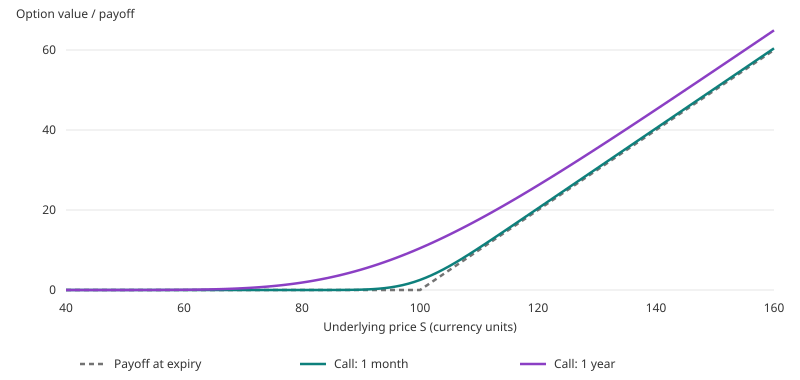

In [6]:
class SVGPlot:
    """Jupyter rich-display protocol; no plotting or display package required."""
    def __init__(self, source):
        self.source = source
    def _repr_svg_(self):
        return self.source

# Deterministic chart computed from the formula; not empirical market data.
width, height = 800, 380
left, right, top, bottom = 66, 26, 30, 90
xmin,xmax,ymin,ymax = 40.,160.,0.,65.
def px(x): return left+(x-xmin)/(xmax-xmin)*(width-left-right)
def py(y): return height-bottom-(y-ymin)/(ymax-ymin)*(height-top-bottom)
svg = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}" role="img" aria-labelledby="bs-plot-title bs-plot-desc">',
       '<title id="bs-plot-title">European call value and terminal payoff</title>',
       '<desc id="bs-plot-desc">Hypothetical Black-Scholes call with K100, r5%, sigma20%, dividend yield0. Compare one year remaining, one month remaining and payoff.</desc>',
       '<rect width="100%" height="100%" fill="white"/>']
for tick in [0,20,40,60]:
    y=py(tick)
    svg.append(f'<path d="M {left} {y:.2f} H {width-right}" stroke="#e6e6e6"/><text x="{left-10}" y="{y+4:.2f}" text-anchor="end" font-family="sans-serif" font-size="12" fill="#333">{tick}</text>')
for tick in [40,60,80,100,120,140,160]:
    svg.append(f'<text x="{px(tick):.2f}" y="{height-bottom+22}" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#333">{tick}</text>')
for tau,color,dash,label in [(0.,"#737373","5 4","Payoff at expiry"),(1/12,"#0e807c","","Call: 1 month"),(1.,"#8b3fc4","","Call: 1 year")]:
    points=[]
    for i in range(121):
        stock=xmin+(xmax-xmin)*i/120
        value=max(stock-K,0.) if tau==0 else black_scholes(stock,K,r,sigma,tau,0.,"call")["price"]
        points.append(f'{px(stock):.2f},{py(value):.2f}')
    svg.append(f'<polyline points="{" ".join(points)}" fill="none" stroke="{color}" stroke-width="2.5" stroke-dasharray="{dash}"/>')
    index=[0.,1/12,1.].index(tau)
    x=80+index*220
    svg.append(f'<path d="M {x} {height-16} h 26" stroke="{color}" stroke-width="2.5" stroke-dasharray="{dash}"/><text x="{x+34}" y="{height-12}" font-family="sans-serif" font-size="12" fill="#333">{label}</text>')
svg.extend([f'<text x="{(left+width-right)/2}" y="{height-bottom+41}" text-anchor="middle" font-family="sans-serif" font-size="12" fill="#333">Underlying price S (currency units)</text>',
            '<text x="16" y="18" font-family="sans-serif" font-size="12" fill="#333">Option value / payoff</text>', '</svg>'])
SVGPlot("".join(svg))

<a id="greeks"></a>

## 9. Greeks: ถ้าสิ่งหนึ่งเปลี่ยน ราคาไวแค่ไหน

Greeks เป็นอนุพันธ์ของราคา โดยเปลี่ยนสิ่งหนึ่งและตรึงสิ่งอื่นไว้ ใช้ทั้งอธิบายรูปทรงของราคาและวัดความไวของพอร์ต สำหรับหุ้นไม่มีปันผล สูตรต่อไปนี้ใช้เมื่อ σ,τ > 0

| Greek | ความหมายเมื่อตรึงสิ่งอื่นไว้ |
|---|---|
| [Delta](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#delta) Δ = V_S | ราคาของ Option เปลี่ยนเท่าไรเมื่อราคาหุ้นเปลี่ยนเล็กน้อย |
| [Gamma](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#gamma) Γ = V_SS | Delta เปลี่ยนเร็วแค่ไหนเมื่อราคาหุ้นเปลี่ยน |
| [Theta](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#theta) Θ = V_t | ราคาไวต่อเวลาปัจจุบันที่เดินไปอย่างไร |
| [Vega](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#vega) ν = V_σ | ราคาไวต่อ volatility อย่างไร |
| [Rho](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#rho) ρᵣ = V_r | ราคาไวต่ออัตราดอกเบี้ยอย่างไร |

**Delta และ Gamma** ของ Call กับ Put เป็น

$$
\begin{aligned}
\Delta_C&=\Phi(d_1),\\
\Delta_P&=\Phi(d_1)-1,\\
\Gamma_C=\Gamma_P&=\frac{\varphi(d_1)}{S\sigma\sqrt\tau}.
\end{aligned}
$$

**Theta** มีทั้งส่วนจากความโค้งและต้นทุนเงิน

$$
\begin{aligned}
\Theta_C&=-\frac{S\sigma\varphi(d_1)}{2\sqrt\tau}\\
&\quad-rKe^{-r\tau}\Phi(d_2),\\[4pt]
\Theta_P&=-\frac{S\sigma\varphi(d_1)}{2\sqrt\tau}\\
&\quad+rKe^{-r\tau}\Phi(-d_2).
\end{aligned}
$$

**Vega และ Rho** วัดความไวต่อพารามิเตอร์

$$
\begin{aligned}
\nu_C=\nu_P&=S\varphi(d_1)\sqrt\tau,\\
(\rho_r)_C&=K\tau e^{-r\tau}\Phi(d_2),\\
(\rho_r)_P&=-K\tau e^{-r\tau}\Phi(-d_2).
\end{aligned}
$$

Θ ใช้อนุพันธ์ตาม **เวลาปัจจุบัน t** โดยตรึง T จึงเท่ากับ −∂V/∂τ หน่วยในตารางเป็นต่อปี ส่วน Vega และ Rho เป็นต่อการเปลี่ยนพารามิเตอร์ **1.00** ถ้ารายงานต่อ 1 percentage point เช่น σ จาก 20% เป็น 21% ต้องหารด้วย 100

ตัวอย่าง Call เดิมให้ Γ ≈ 0.018762, Θ ≈ −6.414028 ต่อปี, Vega ≈ 0.375240 ต่อ volatility 1 percentage point และ Rho ≈ 0.532325 ต่อดอกเบี้ย 1 percentage point ถ้าจะรายงาน Theta ต่อวันต้องระบุ day count เช่น หาร 365 สำหรับวันปฏิทิน ตัวเลขนี้เป็น local sensitivity ไม่ใช่กำไรหรือขาดทุนที่รับประกันในวันถัดไป

เมื่อหุ้นขยับเล็กน้อย δS และเวลาผ่านไป δt การประมาณอันดับสองด้านราคาคือ

$$
\delta V\approx\Delta\,\delta S
+\frac12\Gamma(\delta S)^2+\Theta\,\delta t.
$$

ถ้า volatility เปลี่ยนด้วย ให้เพิ่ม νδσ ในการประมาณอันดับหนึ่งด้านพารามิเตอร์ การตั้ง Delta เป็นศูนย์จึงยังเหลือความไวต่อความโค้งและพารามิเตอร์อื่น

หุ้นมี Gamma เป็นศูนย์ จะปรับ Gamma ของพอร์ตด้วยหุ้นอย่างเดียวไม่ได้ หากถือ Option A จำนวนหนึ่งหน่วย และใช้ Option B มาช่วย เลือกจำนวน n_B = −Γ_A/Γ_B เมื่อ Γ_B ≠ 0 แล้วค่อยใช้หุ้นปรับ Delta รวมกลับเป็นศูนย์ วิธีนี้อาจสร้างความไวต่อ Vega หรือ Theta แบบใหม่ จึงต้องอ่านพอร์ตทั้งชุด

Greeks ยังเชื่อมกันผ่าน PDE:

$$
\Theta+\frac12\sigma^2S^2\Gamma+rS\Delta-rV=0.
$$

สมการนี้เป็นอีกทางตรวจสูตร และอธิบายว่าพจน์ความโค้งกับเวลาถูกเชื่อมด้วยเงื่อนไขการ hedge และต้นทุนเงินอย่างไร

In [7]:
print("Greek units: Delta per stock-price unit; Gamma per stock-price-unit squared.")
print("Theta below is per calendar year, with an additional /365-day convention shown explicitly.")
for kind in ["call", "put"]:
    result = black_scholes(S0,K,r,sigma,T,D,kind)
    print(f"{kind:4s}: Delta={result['delta']:.9f}, Gamma={result['gamma']:.9f}, Theta/year={result['theta']:.9f}, Theta/365-day={result['theta']/365:.9f}")
    print(f"      Vega/1pp={result['vega']/100:.9f}, Rho/1pp={result['rho']/100:.9f}")
    # Finite differences independently verify implementation and the time sign.
    hS, hparam = .01, 1e-5
    def value(s=S0, vol=sigma, rate=r, tau=T):
        return black_scholes(s,K,rate,vol,tau,D,kind)["price"]
    delta_fd = (value(s=S0+hS)-value(s=S0-hS))/(2*hS)
    gamma_fd = (value(s=S0+hS)-2*value()+value(s=S0-hS))/(hS*hS)
    theta_fd = -(value(tau=T+hparam)-value(tau=T-hparam))/(2*hparam)
    vega_fd = (value(vol=sigma+hparam)-value(vol=sigma-hparam))/(2*hparam)
    rho_fd = (value(rate=r+hparam)-value(rate=r-hparam))/(2*hparam)
    for greek,approx in [("delta",delta_fd),("gamma",gamma_fd),("theta",theta_fd),("vega",vega_fd),("rho",rho_fd)]:
        close(result[greek],approx,2e-7)
    residual = result["theta"]+.5*sigma*sigma*S0*S0*result["gamma"]+(r-D)*S0*result["delta"]-r*result["price"]
    close(residual,0)
    print(f"      PDE residual={residual:.3e}; central-difference Greeks passed.")
print("Vega=37.52 per 1.00 volatility is about 0.3752 per 1 percentage point, not 37.52 per point.")

Greek units: Delta per stock-price unit; Gamma per stock-price-unit squared.
Theta below is per calendar year, with an additional /365-day convention shown explicitly.
call: Delta=0.636830651, Gamma=0.018762017, Theta/year=-6.414027546, Theta/365-day=-0.017572678
      Vega/1pp=0.375240347, Rho/1pp=0.532324815
      PDE residual=2.220e-16; central-difference Greeks passed.
put : Delta=-0.363169349, Gamma=0.018762017, Theta/year=-1.657880424, Theta/365-day=-0.004542138
      Vega/1pp=0.375240347, Rho/1pp=-0.418904609
      PDE residual=7.216e-16; central-difference Greeks passed.
Vega=37.52 per 1.00 volatility is about 0.3752 per 1 percentage point, not 37.52 per point.


<a id="discrete-hedging"></a>

## 10. เมื่อปรับ hedge ได้เป็น step

สูตร Black–Scholes อาศัยการปรับ Delta ต่อเนื่อง แต่การทดลองบนคอมพิวเตอร์และการซื้อขายต้องเลือกเวลาเป็นช่วง ๆ เริ่มด้วย X₀ = V₀, Δ₀ = V_S(S₀,0) และ M₀ = V₀ − Δ₀S₀ จากนั้นถือหุ้นเดิมตลอดหนึ่ง time step

เมื่อถึง tᵢ₊₁ มูลค่าก่อนปรับพอร์ตคือ

$$
X_{i+1}^{-}=\Delta_iS_{i+1}+M_i e^{r\Delta t}.
$$

ถ้ายังไม่ถึง T ให้คำนวณ Delta ใหม่ แล้วใช้เงินในพอร์ตซื้อหรือขายหุ้น

$$
\Delta_{i+1}=V_S(S_{i+1},t_{i+1}),\qquad
M_{i+1}=X_{i+1}^{-}-\Delta_{i+1}S_{i+1}.
$$

มูลค่าหลังปรับยังเท่ากับก่อนปรับ จึงเป็น self-financing ส่วน ณ T ให้ชำระ payoff เลย ไม่ต้องหา Delta ที่มุมของ payoff เพื่อปรับพอร์ตอีกครั้ง

ห้องทดลองจำลองราคาภายใต้ ℙ ด้วย μ = 8%, σ = 20%, S₀ = K = 100, r = 5% และอายุ 1 ปี ใช้ exact GBM ที่จุดเวลาซึ่งเลือก และสร้าง Brownian increments บนตารางละเอียดเดียวกัน การเลือก 16, 64 หรือ 256 step จึงใช้เส้นทางเดียวกัน ณ จุดเวลาที่ตรงกัน รวมถึงราคา S_T เดียวกัน

**Residual = มูลค่าพอร์ต ณ T − payoff** ค่าบวกคือเงินเหลือหลังจ่ายภาระ Option ค่าลบคือเงินขาด สำหรับผู้ขายหนึ่งหน่วยที่รับ premium มาตั้งพอร์ตตามสูตรและใช้สมมติฐานนี้ Residual จึงวัดผลของการ hedge เป็นช่วง ๆ ได้

อย่าสรุปจาก seed เดียวว่าเพิ่ม step แล้วขนาด Residual ต้องลดทุกครั้ง การปรับถี่ขึ้นมีผลต่อการลู่เข้าของกลยุทธ์ภายใต้แบบจำลอง แต่ความคลาดเคลื่อนบนเส้นทางใดเส้นทางหนึ่งอาจไม่ลดแบบเรียงลำดับ ต้องดูหลายเส้นทางเพื่อศึกษาการกระจายของ hedging error

| สิ่งที่คลาดเคลื่อน | เกิดจากอะไรในบริบทนี้ |
|---|---|
| Discrete hedging error | ค้าง Delta ระหว่างเวลา rebalance แม้จำลอง GBM ที่จุดเวลาได้แบบ exact |
| Monte Carlo sampling error | ใช้จำนวนเส้นทางจำกัดเพื่อประมาณราคาเฉลี่ยหรือสถิติของ error |
| Model error | โลกที่นำไปใช้ไม่ตรงกับสมมติฐาน เช่น volatility ไม่คงที่หรือมีการกระโดด |

เพิ่มจำนวนเส้นทางช่วยลด sampling error ส่วนเพิ่มความถี่ hedge เปลี่ยน discrete hedging error ทั้งสองอย่างไม่ได้ยืนยันว่าแบบจำลองตลาดถูกต้อง และเมื่อมีค่าซื้อขาย การปรับถี่ขึ้นก็มีต้นทุนที่ห้องทดลองนี้ยังไม่ได้รวม

In [8]:
# Simulate ONE finest Brownian path, then sum its increments for every hedge grid.
# D=0: no dividend cash flows. Price drift mu is a physical scenario assumption.
hedge_mu, hedge_seed, finest_N = .08, 2026091402, 256
rng = random.Random(hedge_seed)
fine_dw = [math.sqrt(T/finest_N)*rng.gauss(0,1) for _ in range(finest_N)]
WT = math.fsum(fine_dw)
exact_terminal = S0*math.exp((hedge_mu-.5*sigma*sigma)*T+sigma*WT)

def discrete_hedge(N):
    if N <= 0 or finest_N % N:
        raise ValueError("N must be a positive divisor of the finest grid")
    dt, group = T/N, finest_N//N
    increments = [math.fsum(fine_dw[j:j+group]) for j in range(0,finest_N,group)]
    close(math.fsum(increments),WT)
    S = S0
    initial = black_scholes(S,K,r,sigma,T,0.,"call")
    shares = initial["delta"]
    cash = initial["price"]-shares*S
    ledger = [(0.,S,shares*S+cash)]
    max_financing_residual = 0.
    for j,dw in enumerate(increments,1):
        cash *= math.exp(r*dt)  # Accrue cash, including interest on borrowing.
        S *= math.exp((hedge_mu-.5*sigma*sigma)*dt+sigma*dw)
        portfolio_before = shares*S+cash
        if j < N:  # At expiry settle payoff; do not compute singular expiry Delta.
            new_shares = black_scholes(S,K,r,sigma,T-j*dt,0.,"call")["delta"]
            cash -= (new_shares-shares)*S  # Pay for every rebalancing trade from cash.
            shares = new_shares
            financing_residual = shares*S+cash-portfolio_before
            max_financing_residual = max(max_financing_residual,abs(financing_residual))
            close(financing_residual,0)
        ledger.append((j*dt,S,shares*S+cash))
    close(S,exact_terminal)
    payoff = max(S-K,0.)
    return dict(N=N, terminal=S, portfolio=shares*S+cash, payoff=payoff,
                error=shares*S+cash-payoff, ledger=ledger,
                financing_residual=max_financing_residual)

hedge_results = [discrete_hedge(N) for N in [16,64,256]]
print(f"Same nested Brownian path: seed={hedge_seed}, finest N={finest_N}, physical mu={hedge_mu:.2%}, D=0.")
print("This Notebook is an independent seeded example; its path and residual need not match the website.")
print("Error = long replicating stock/cash portfolio - call payoff (equivalently hedged short-call terminal P&L).")
for result in hedge_results:
    print(f"{result['N']:3d} step: terminal stock={result['terminal']:.9f}, portfolio={result['portfolio']:.9f}, payoff={result['payoff']:.9f}, error={result['error']:+.9f}")
    print(f"          max self-financing trade residual={result['financing_residual']:.3e}")
print("Initial portfolio is funded by the model premium. There is no cash injection at rebalances and no final rebalance.")
print("One path's hedging error need not fall monotonically as step count increases; no such assertion is made.")
print("This simulation excludes transaction costs, jumps, stochastic volatility, and model misspecification.")

Same nested Brownian path: seed=2026091402, finest N=256, physical mu=8.00%, D=0.
This Notebook is an independent seeded example; its path and residual need not match the website.
Error = long replicating stock/cash portfolio - call payoff (equivalently hedged short-call terminal P&L).
 16 step: terminal stock=90.693025474, portfolio=0.908393380, payoff=0.000000000, error=+0.908393380
          max self-financing trade residual=3.553e-15
 64 step: terminal stock=90.693025474, portfolio=-0.020831135, payoff=0.000000000, error=-0.020831135
          max self-financing trade residual=7.105e-15
256 step: terminal stock=90.693025474, portfolio=0.075592464, payoff=0.000000000, error=+0.075592464
          max self-financing trade residual=7.105e-15
Initial portfolio is funded by the model premium. There is no cash injection at rebalances and no final rebalance.
One path's hedging error need not fall monotonically as step count increases; no such assertion is made.
This simulation excludes tr

<a id="extensions"></a>

## 11. เงินปันผล FX และต้นทุนถือสินค้าเปลี่ยนตรงไหน

ถ้าหุ้นจ่ายเงินปันผลด้วย **continuous proportional yield D** หุ้นที่ถือในพอร์ตสร้างเงินสดเพิ่ม DΔSdt สมการราคาจึงเปลี่ยนเป็น

$$
V_t+\frac12\sigma^2S^2V_{SS}+(r-D)SV_S-rV=0.
$$

ภายใต้ ℚ drift ของ **ราคาไม่รวมปันผล** เป็น r − D โดย discount ที่ r เช่นเดิม กำหนดใหม่ว่า

$$
d_1=\frac{\ln(S/K)+(r-D+\tfrac12\sigma^2)\tau}{\sigma\sqrt\tau},
\qquad d_2=d_1-\sigma\sqrt\tau.
$$

แล้วได้

$$
C=Se^{-D\tau}\Phi(d_1)-Ke^{-r\tau}\Phi(d_2),
\qquad
P=Ke^{-r\tau}\Phi(-d_2)-Se^{-D\tau}\Phi(-d_1).
$$

Delta ของ Call เป็น e⁻ᴰτΦ(d₁) จึงไม่เท่ากับ Φ(d₁) เฉย ๆ อีกแล้ว เราใช้ D แทน dividend yield เพื่อไม่ให้ชนกับ q ที่เคยใช้เป็น pricing probability ในต้นไม้

| สินทรัพย์อ้างอิง | การอ่านพจน์ carry |
|---|---|
| หุ้นที่มี yield D คงที่ | ใช้ r − D; ไม่ใช่สูตรทั่วไปสำหรับปันผลเงินสดเป็นก้อนตามวัน |
| FX ที่ S เป็นเงินในประเทศต่อหนึ่งหน่วยเงินต่างประเทศ | เงินต่างประเทศสร้างดอกเบี้ย r_f จึงแทน D ด้วย r_f และ r ด้วย r_d; ผลเป็นมูลค่าในเงินในประเทศ |
| สินค้าที่มีต้นทุนเก็บรักษา κ ต่อปีเป็นสัดส่วนของราคา | ในแบบจำลองถือและซื้อขายสินค้าได้อย่างไม่มีข้อจำกัดและไม่มี convenience yield ใช้ carry r + κ หรือเทียบเท่า D = −κ |

ต้นทุนสินค้าแบบนี้เป็นกรณีลดรูป การเก็บรักษาเป็นจำนวนเงินคงที่ สิทธิประโยชน์จากการมีสินค้าจริง และข้อจำกัดการ short ต้องวิเคราะห์เพิ่ม ห้องทดลองและสูตร Greeks ในส่วนก่อนใช้ **หุ้นไม่มีปันผล** ตามที่ระบุไว้

In [9]:
dividend = .03
call_D = black_scholes(S0,K,r,sigma,T,dividend,"call")
put_D = black_scholes(S0,K,r,sigma,T,dividend,"put")
digital_call = math.exp(-r*T)*N(call_D["d2"])
digital_put = math.exp(-r*T)*N(-call_D["d2"])
close(digital_call+digital_put,math.exp(-r*T))
print(f"With dividend yield D=3%: call={call_D['price']:.9f}, put={put_D['price']:.9f}.")
print(f"One-unit cash digital: call={digital_call:.9f}, put={digital_put:.9f}; sum={digital_call+digital_put:.9f}=PV(1).")
print(f"Q(S_T>K)=N(d2)={N(call_D['d2']):.9f}; call Delta=e^(-D*tau)*N(d1)={call_D['delta']:.9f}.")
print("Delta is not this risk-neutral exercise probability. Strike equality has probability zero for tau>0 and sigma>0.")
print("These closed forms are European. American/Bermudan contracts require an exercise rule in valuation.")

With dividend yield D=3%: call=8.652528554, put=6.730917649.
One-unit cash digital: call=0.475614712, put=0.475614712; sum=0.951229425=PV(1).
Q(S_T>K)=N(d2)=0.500000000; call Delta=e^(-D*tau)*N(d1)=0.562139998.
Delta is not this risk-neutral exercise probability. Strike equality has probability zero for tau>0 and sigma>0.
These closed forms are European. American/Bermudan contracts require an exercise rule in valuation.


<a id="early-exercise"></a>

## 12. ถ้าเลือกใช้สิทธิก่อนหมดอายุได้

[American option](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#american-option) เพิ่มสิทธิเลือกเวลาใช้สิทธิ จึงต้องมีมูลค่าอย่างน้อยเท่ากับ European ที่มีเงื่อนไขอื่นเหมือนกัน และอย่างน้อยเท่ากับ payoff จากการใช้สิทธิทันที

$$
V_A(S,t)\ge V_E(S,t),\qquad V_A(S,t)\ge g(S).
$$

ต้องเปรียบเทียบสองทางเลือก ณ แต่ละจุด: **ใช้สิทธิรับ g(S) ตอนนี้** หรือ **ถือต่อเพื่อรักษาสิทธิ** ในบริเวณที่ถือต่อ มูลค่ายังเป็นไปตาม PDE เดิม แต่เส้นแบ่งระหว่างสองบริเวณเป็นส่วนหนึ่งของคำตอบ เรียกว่า [exercise boundary](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#exercise-boundary)

สำหรับ American Put มาตรฐานในแบบจำลอง diffusion เมื่อมีขอบเขตใช้สิทธิที่เรียบ S*(t) จะมีทั้ง value matching และ smooth pasting

$$
V_A(S^*(t),t)=K-S^*(t),\qquad
(V_A)_S(S^*(t),t)=-1.
$$

มูลค่าและความชันจึงต่อกับเส้น payoff ที่ขอบเขต ภายใต้เงื่อนไขความเรียบของโจทย์นี้ ไม่ใช่กฎที่นำไปใช้กับทุก payoff หรือ jump model ได้โดยไม่ตรวจสมมติฐาน

**Call ไม่มีปันผลและ r ≥ 0** ไม่ได้ประโยชน์เพิ่มจากการใช้สิทธิก่อนหมดอายุภายใต้สมมติฐานมาตรฐาน เพราะ European Call มีขอบล่าง max(S − Ke⁻ʳτ,0) ≥ max(S − K,0) การจ่าย K เร็วขึ้นยังทำให้เสียสิทธิเลือกในอนาคต จึงมีราคา American เท่ากับ European ในกรณีนี้

Put อาจคุ้มที่จะรับ K ก่อนเมื่ออยู่ลึกในเงินและต้นทุนเงินมีความสำคัญ ส่วน Call ที่มีปันผลก็อาจใช้สิทธิเร็วได้ เงื่อนไข r ≥ 0 ของข้อสรุป Call ไม่มีปันผลไม่ควรถูกตัดทิ้งเมื่อพิจารณาดอกเบี้ยติดลบ

ถ้าใช้สิทธิได้เฉพาะวันที่กำหนด เรียก **Bermudan option** ที่แต่ละวันใช้สิทธิได้ ให้เทียบมูลค่าถือต่อกับ payoff เหมือนขั้น max ในต้นไม้ราคา สูตร European Call/Put ข้างต้นจึงไม่ได้แทนคำตอบ American Put โดยอัตโนมัติ

<a id="model-limits"></a>

## 13. สูตรราคาเป็นจุดเริ่มต้นของการอ่านความเสี่ยง

แบบจำลองให้ผลที่ชัด เพราะสมมติฐานชัด: volatility คงที่ ช็อกต่อเนื่อง พอร์ตปรับได้ต่อเนื่อง และไม่มีต้นทุนซื้อขาย เมื่อนำไปเทียบกับข้อมูลหรือใช้ hedge ต้องแยกความผิดพลาดของการคำนวณออกจากความไม่ตรงของสมมติฐานเหล่านี้

อีกวิธีใช้สูตรคือกลับโจทย์: ตรึง S,K,r,τ แล้วหาค่า σ ที่ทำให้ราคาในสูตรตรงกับราคาที่สังเกต เรียก **[implied volatility](https://nutdnuy.github.io/quantitative-finance-notes/glossary.html#implied-volatility)** ภายใต้สมมติฐานที่เลือก สำหรับ European vanilla และราคาที่อยู่ภายในขอบเขต no-arbitrage อย่างเคร่งครัด Vega ที่เป็นบวกช่วยให้แก้ย้อนหา σ ได้เพียงค่าเดียว

ถ้าใช้ราคาคนละ strike หรือ maturity แล้วได้ implied volatility ไม่เท่ากัน เราไม่สามารถอธิบายราคาทั้งชุดด้วย σ คงที่เพียงตัวเดียวได้ การใช้สูตรเป็นภาษารายงานราคาจึงไม่ได้ยืนยันว่า GBM ที่มี σ คงที่เป็นคำอธิบายตลาดที่ครบถ้วน และ implied volatility ก็ไม่ใช่คำรับประกันความผันผวนที่กำลังจะเกิด

<a id="exercises"></a>

## ลองเชื่อมทั้งบท

1. ผู้วิเคราะห์สองคนให้ μ ต่างกัน แต่ใช้ S,K,r,σ,τ และสมมติฐานเดียวกัน ราคา European Call ในแบบจำลองนี้ควรต่างกันหรือไม่
2. ถ้า Call มี Delta 0.6 และ Gamma 0.02 การถือ Call หนึ่งหน่วยแล้ว short หุ้น 0.6 หน่วยทำให้ Gamma เป็นศูนย์ด้วยหรือไม่
3. ทำไมในตัวอย่าง Φ(d₂) ≈ 0.5596 แต่ Delta ≈ 0.6368 จึงไม่ขัดกัน
4. ถ้า Vega ต่อ volatility 1 percentage point เท่ากับ 0.3752 เมื่อ volatility เพิ่มจาก 20% เป็น 22% ราคาเปลี่ยนประมาณเท่าไร โดยตรึงค่าอื่นไว้
5. ถ้าพอร์ตก่อน rebalance มีมูลค่า 12 หุ้นราคา 100 และ Delta ใหม่ 0.65 บัญชีเงินสดหลังปรับต้องเป็นเท่าไร
6. เพิ่มความถี่ hedge จาก 64 เป็น 256 step แล้ว Residual ของ seed หนึ่งใหญ่ขึ้น แปลว่าแนวคิดลู่เข้าผิดหรือไม่
7. ใช้สูตร European Put ตั้งราคา American Put ได้เสมอหรือไม่

**เปิดเฉลยพร้อมเหตุผล**

1. **ไม่ต่าง** เพราะ μ ถูกหักล้างในการเลียนแบบ แต่ความเห็นต่อราคาหุ้นจริงและความเสี่ยงยังต่างกันได้
2. **ไม่เป็นศูนย์** หุ้นมี Gamma ศูนย์ จึงเหลือ Gamma 0.02 เท่าเดิม ณ จุดนั้น
3. Φ(d₂) เป็นโอกาสจบเหนือ K ภายใต้ ℚ ส่วน Delta วัดความไวของราคา Call ต่อ S และมีการถ่วงขนาดราคาปลายทางอยู่ในการคำนวณ
4. เพิ่มประมาณ **0.7504 หน่วยเงิน** จาก 0.3752 × 2 เป็น local linear approximation; Vega เองอาจเปลี่ยนระหว่างทาง
5. **−53 หน่วยเงิน** เพราะ 12 − 0.65 × 100 = −53 คือเงินกู้ และมูลค่าหุ้นรวมเงินสดยังเท่ากับ 12
6. **ไม่จำเป็น** การลู่เข้าไม่ได้บังคับให้ขนาด error ของทุกเส้นทางลดลงในทุกความละเอียด ต้องใช้เส้นทางร่วมและดูการกระจายของ error จากหลายเส้นทาง
7. **ไม่ได้** American Put มีสิทธิใช้เร็วและอาจมีมูลค่าเพิ่ม ต้องแก้โจทย์ที่รวมการตัดสินใจใช้สิทธิด้วย

<a id="notebook"></a>

## ทดลองต่อด้วย Python

[ดาวน์โหลด Notebook บท Black-Scholes Model](https://nutdnuy.github.io/quantitative-finance-notes/notebooks/black-scholes-model.ipynb) เพื่อคำนวณ Call/Put และ Greeks ตรวจ put–call parity ประมาณราคาด้วย Monte Carlo ภายใต้ ℚ และเปรียบเทียบ discrete Delta hedge บน Brownian path เดียวกัน โค้ดใช้ Python standard library พร้อม seed และผลการรัน

<a id="sources"></a>

## อ่านประกอบ

- Martin Haugh, [The Black-Scholes Model](https://www.columbia.edu/~mh2078/FoundationsFE/BlackScholes.pdf) — เอกสารมหาวิทยาลัยสำหรับอ่านเรื่องพอร์ต self-financing, PDE และ risk-neutral valuation เพิ่มเติม
- MIT OpenCourseWare, [Black–Scholes Formula & Risk-neutral Valuation](https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-with-applications-in-finance-fall-2013/d19208c017ada04f9261cfb41ab8d702_MIT18_S096F13_lecnote19.pdf) — มุมมองสูตรราคาผ่านการแจกแจงและค่าเฉลี่ย

ตัวเลขและกราฟทดลองในบทนี้เป็นตัวอย่างสมมติที่คำนวณจากแบบจำลอง ไม่ใช่ข้อมูลราคาตลาด